In [1]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Romanian-RRT"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

connected to port: 55284


In [2]:
all_matches = corpus.search(grewpy.Request("pattern{X[upos=VERB]}"), clustering_parameter=['X.lemma'])

In [3]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [4]:
with open("patterns_ro_verbs.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [5]:
data = { k : list() for k in matches }
for verb, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[verb].append(formatted_features)

In [7]:
unique_verb = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2v = {i : feat for i, feat in enumerate(unique_verb) }
v2idx = {feat : i for i, feat in idx2v.items()}

In [8]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[v2idx[adv], feature2idx[feature]] += 1
    X[v2idx[adv]] = X[v2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(468, 386)


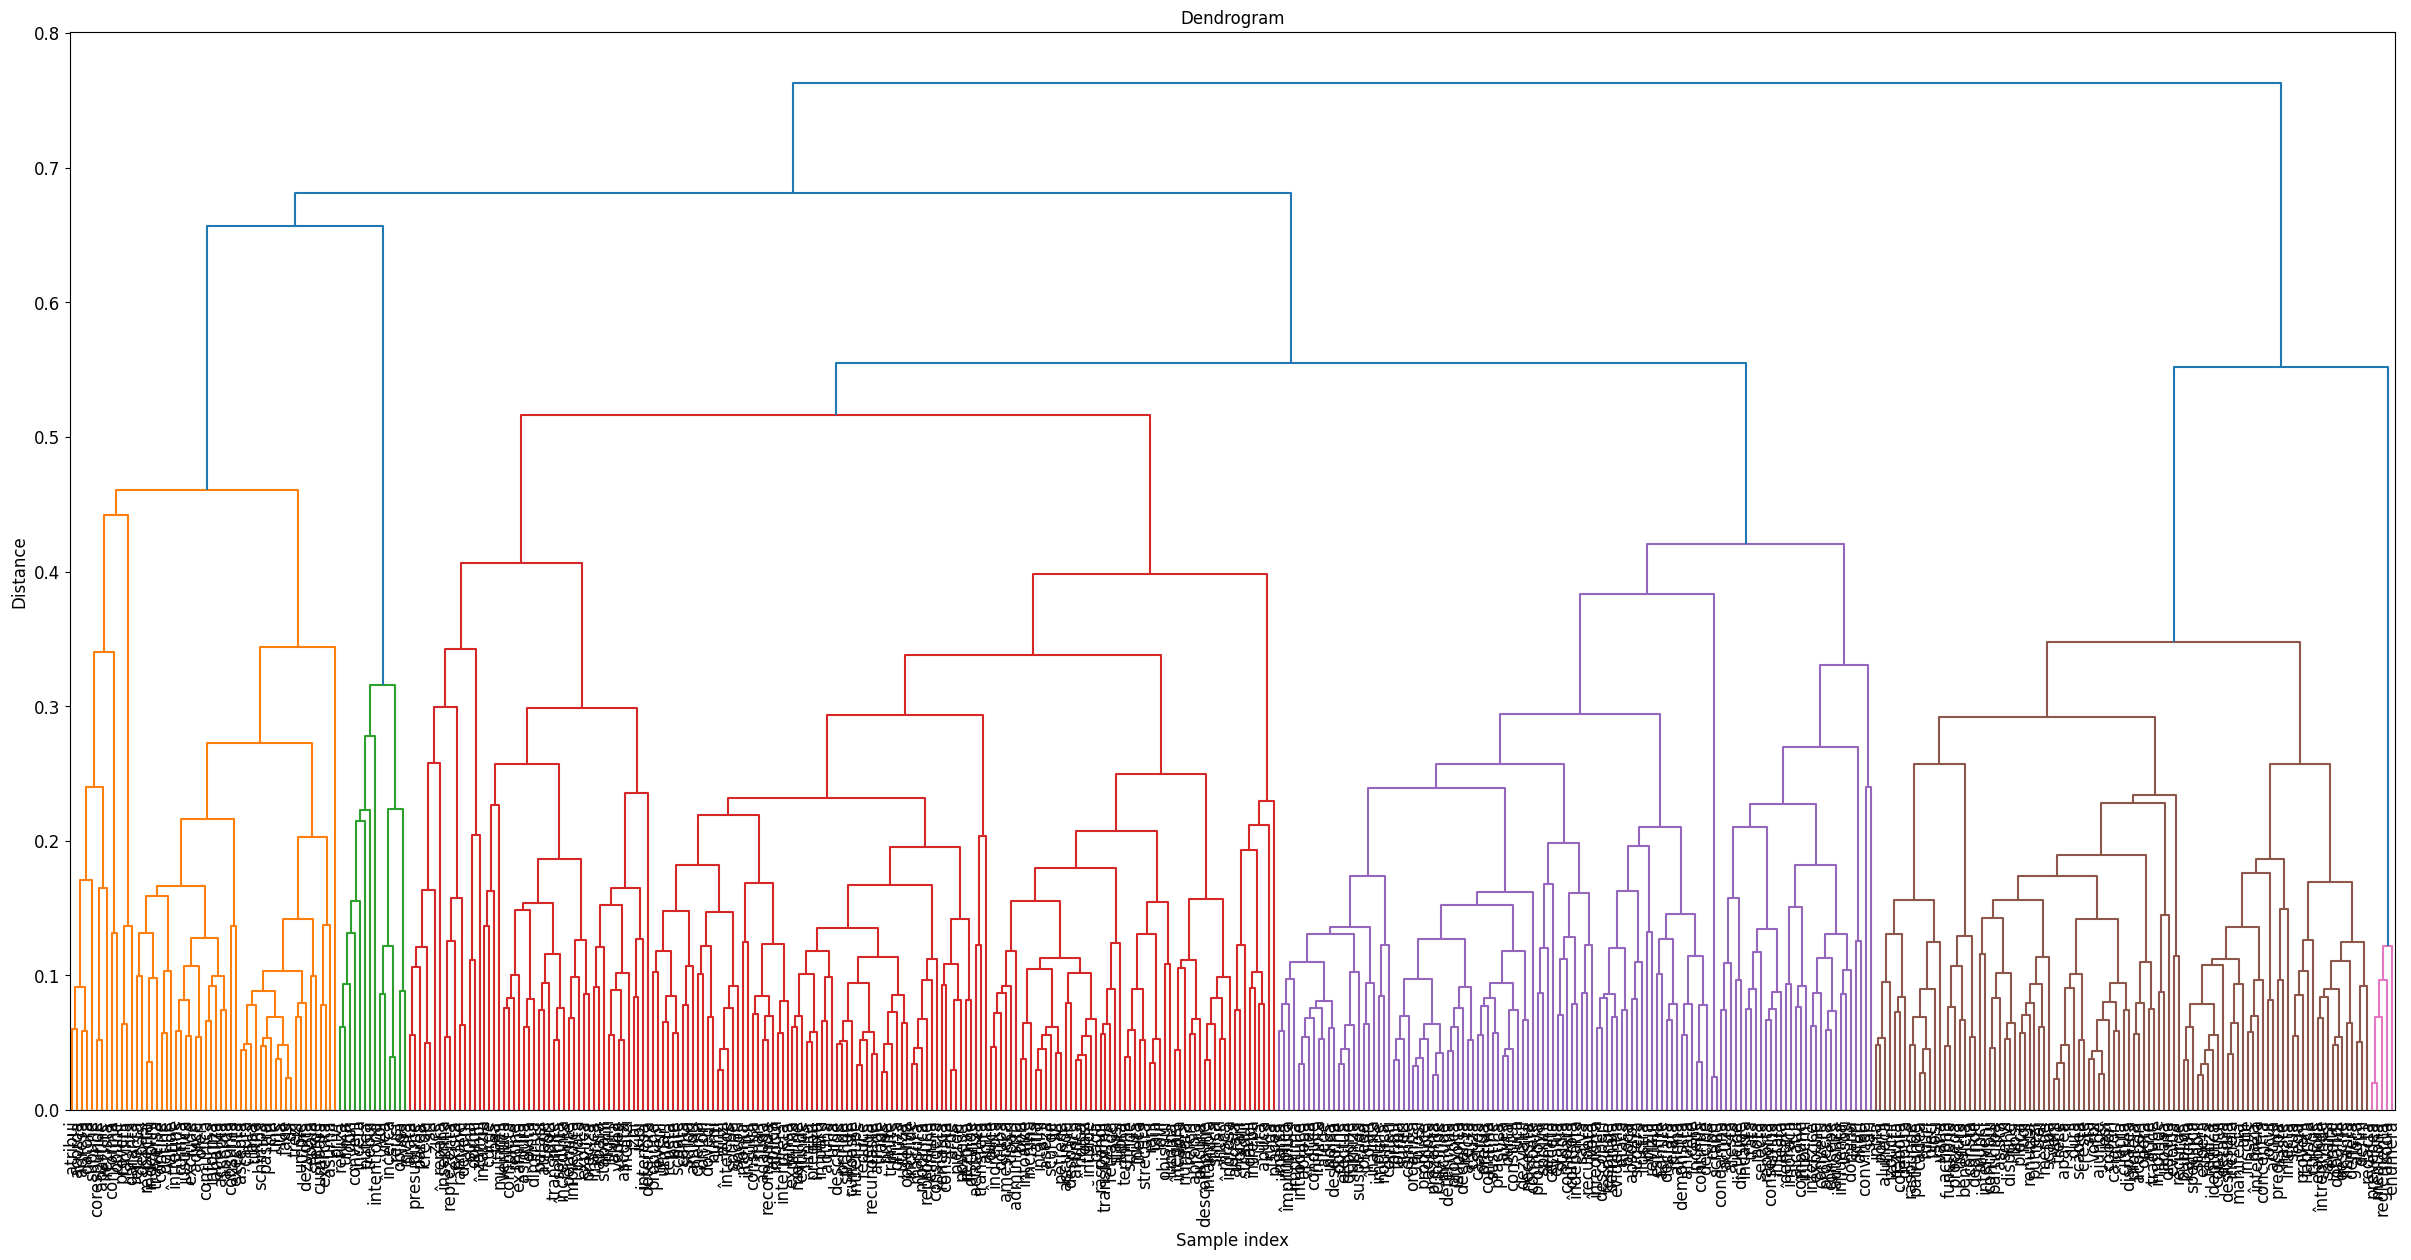

In [9]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(30, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_verb],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [10]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=50)
print(f'Optimal number of clusters: {optimal_clusters}')
print(X.shape)

Number of clusters: 2, Silhouette Score: 0.11196600263417124
Number of clusters: 3, Silhouette Score: 0.06943427798350002
Number of clusters: 4, Silhouette Score: 0.06068497052867445
Number of clusters: 5, Silhouette Score: 0.09454523782673807
Number of clusters: 6, Silhouette Score: 0.09240179980651629
Number of clusters: 7, Silhouette Score: 0.10281472862055294
Number of clusters: 8, Silhouette Score: 0.08252890392238982
Number of clusters: 9, Silhouette Score: 0.09036441871735544
Number of clusters: 10, Silhouette Score: 0.09739427770288123
Number of clusters: 11, Silhouette Score: 0.10290677217062164
Number of clusters: 12, Silhouette Score: 0.10223601931083602
Number of clusters: 13, Silhouette Score: 0.10231126305467914
Number of clusters: 14, Silhouette Score: 0.11559677947873134
Number of clusters: 15, Silhouette Score: 0.11255897822614332
Number of clusters: 16, Silhouette Score: 0.11296621857364708
Number of clusters: 17, Silhouette Score: 0.1137335104477039
Number of cluster

In [11]:
# see what there is in each cluster
labels = fcluster(linked, 2, criterion='maxclust')
clusters = {i: [] for i in range(1,3)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_verb[member]}')

Cluster 1:
  acoperi
  activa
  acționa
  ajunge
  aloca
  aluneca
  apărea
  apăsa
  asista
  asocia
  baza
  beneficia
  calcula
  circula
  coborî
  colabora
  concentra
  consta
  construi
  contribui
  crește
  culege
  cădea
  călători
  debuta
  defini
  depinde
  descrie
  desfășura
  detașa
  discuta
  dispune
  dispărea
  dobândi
  dura
  elabora
  elibera
  emite
  enumera
  evolua
  fabrica
  fi
  figura
  finanța
  fugi
  funcționa
  genera
  identifica
  ieși
  infecta
  interveni
  intra
  izbucni
  lega
  lipsi
  locui
  lucra
  manifesta
  menționa
  merge
  munci
  muri
  naște
  opera
  participa
  pieri
  pleca
  porni
  preocupa
  prevedea
  proceda
  proteja
  proveni
  publica
  putrezi
  pătrunde
  realiza
  recurge
  redacta
  reglementa
  renunța
  rezulta
  răspunde
  scrie
  scădea
  scăpa
  servi
  situa
  sosi
  specifica
  sta
  stabili
  săvârși
  traduce
  trece
  trăi
  uni
  varia
  veni
  vorbi
  împinge
  încheia
  înscrie
  întemeia
  întreprinde
C

In [12]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_tsne[:, 0],
    'PCA2': X_tsne[:, 1],
    'Cluster': labels,
    'Word': unique_verb
})
# pca1_min, pca1_max = df['PCA1'].min(), df['PCA1'].max()
# pca2_min, pca2_max = df['PCA2'].min(), df['PCA2'].max()
# Create a scatter plot with Plotly
fig = go.Figure()

# Add traces for each cluster
for cluster in range(1, optimal_clusters + 1):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hoverinfo='text'
    ))

# Update layout with dropdown menu
fig.update_layout(
    title='Word Clusters',
    xaxis_title='tsne1',
    yaxis_title='tsne2',
    width=1600,  # Set the width of the figure
    height=800,
    # xaxis=dict(range=[pca1_min, pca1_max]),
    # yaxis=dict(range=[pca2_min, pca2_max]),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * optimal_clusters},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(optimal_clusters)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, optimal_clusters + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()